In [1]:
import pandas as pd
import numpy as np

# 1. read data
df = pd.read_csv("/Users/xinyuguo/Desktop/ncr/ec/ncr_existing_buffer_mapped_account.csv")

# 2. basic cleaning
df = df.copy()
df = df[df["account_nbr"].notna()].copy()

for c in ["new_tgt_cnt_4mi", "new_tgt_cnt_3mi", "new_tgt_cnt_2mi"]:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

# 3. aggregate to account level
account_df = (
    df.groupby("account_nbr", dropna=True)
      .agg(
          customer_name=("customer_name", lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]),
          site_count=("account_site_nbr", "nunique"),
          state_count=("state", "nunique"),

          avg_tgt_4mi=("new_tgt_cnt_4mi", "mean"),
          avg_tgt_3mi=("new_tgt_cnt_3mi", "mean"),
          avg_tgt_2mi=("new_tgt_cnt_2mi", "mean"),

          med_tgt_4mi=("new_tgt_cnt_4mi", "median"),
          med_tgt_3mi=("new_tgt_cnt_3mi", "median"),
          med_tgt_2mi=("new_tgt_cnt_2mi", "median"),

          total_tgt_4mi=("new_tgt_cnt_4mi", "sum"),
          total_tgt_3mi=("new_tgt_cnt_3mi", "sum"),
          total_tgt_2mi=("new_tgt_cnt_2mi", "sum"),

          lat_mean=("latitude", "mean"),
          lon_mean=("longitude", "mean"),
          lat_std=("latitude", "std"),
          lon_std=("longitude", "std")
      )
      .reset_index()
)

# 4. fill spread features for single-site accounts
account_df["lat_std"] = account_df["lat_std"].fillna(0)
account_df["lon_std"] = account_df["lon_std"].fillna(0)

# 5. log features for large accounts
account_df["log_site_count"] = np.log1p(account_df["site_count"])
account_df["log_total_tgt_4mi"] = np.log1p(account_df["total_tgt_4mi"])
account_df["log_total_tgt_3mi"] = np.log1p(account_df["total_tgt_3mi"])
account_df["log_total_tgt_2mi"] = np.log1p(account_df["total_tgt_2mi"])

# save
account_df.to_csv("/Users/xinyuguo/Desktop/ncr/ec/existing_account_unsupervised_base.csv", index=False)

print(account_df.shape)
print(account_df.head())

(568, 21)
  account_nbr  customer_name  site_count  state_count  avg_tgt_4mi  \
0    10009370         Macy's           1            1          7.0   
1    10011177         Macy's           1            1         28.0   
2      100342  Family Dollar           1            1         18.0   
3    10107516         Macy's           1            1          1.0   
4    10110052        Walmart           1            1          4.0   

   avg_tgt_3mi  avg_tgt_2mi  med_tgt_4mi  med_tgt_3mi  med_tgt_2mi  ...  \
0          5.0          1.0          7.0          5.0          1.0  ...   
1         18.0          3.0         28.0         18.0          3.0  ...   
2          7.0          1.0         18.0          7.0          1.0  ...   
3          1.0          1.0          1.0          1.0          1.0  ...   
4          2.0          0.0          4.0          2.0          0.0  ...   

   total_tgt_3mi  total_tgt_2mi  lat_mean  lon_mean  lat_std  lon_std  \
0            5.0            1.0    40.893   -

In [2]:
feature_cols = [
    "log_site_count",
    "state_count",

    "avg_tgt_4mi",
    "avg_tgt_3mi",
    "avg_tgt_2mi",

    "med_tgt_4mi",
    "med_tgt_3mi",
    "med_tgt_2mi",

    "log_total_tgt_4mi",
    "log_total_tgt_3mi",
    "log_total_tgt_2mi",

    "lat_std",
    "lon_std"
]

In [3]:
from sklearn.preprocessing import RobustScaler

X = account_df[feature_cols].copy()

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

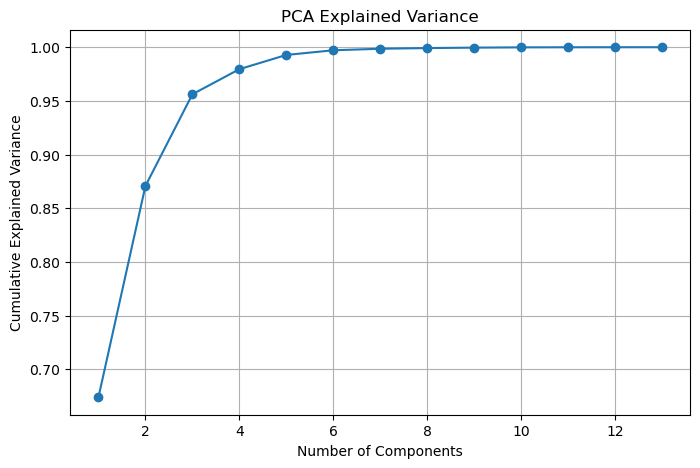

In [4]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA()
X_pca_all = pca.fit_transform(X_scaled)

explained = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained)+1), explained, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

In [5]:
from sklearn.decomposition import PCA

pca_final = PCA(n_components=3, random_state=42)
X_pca = pca_final.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("PCA shape:", X_pca.shape)
print("Explained variance ratio:", pca_final.explained_variance_ratio_)
print("Cumulative explained variance:", pca_final.explained_variance_ratio_.cumsum())

Original shape: (568, 13)
PCA shape: (568, 3)
Explained variance ratio: [0.67389327 0.19681974 0.08547225]
Cumulative explained variance: [0.67389327 0.87071301 0.95618526]


In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append((k, score))

print("Silhouette scores by k:")
for k, score in scores:
    print(f"k={k}: {score:.4f}")

Silhouette scores by k:
k=2: 0.8528
k=3: 0.7317
k=4: 0.4884
k=5: 0.6029
k=6: 0.4822


k=2

In [7]:
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=20)
account_df["cluster_2"] = kmeans_2.fit_predict(X_pca)

In [8]:
account_df["PC1"] = X_pca[:, 0]
account_df["PC2"] = X_pca[:, 1]
account_df["PC3"] = X_pca[:, 2]

In [9]:
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=20)
account_df["cluster_3"] = kmeans_3.fit_predict(X_pca)

In [10]:
cluster2_profile = (
    account_df.groupby("cluster_2")
    .agg(
        account_count=("account_nbr", "nunique"),
        avg_site_count=("site_count", "mean"),
        med_site_count=("site_count", "median"),
        avg_state_count=("state_count", "mean"),

        avg_avg_tgt_4mi=("avg_tgt_4mi", "mean"),
        avg_avg_tgt_3mi=("avg_tgt_3mi", "mean"),
        avg_avg_tgt_2mi=("avg_tgt_2mi", "mean"),

        med_avg_tgt_4mi=("avg_tgt_4mi", "median"),
        med_avg_tgt_3mi=("avg_tgt_3mi", "median"),
        med_avg_tgt_2mi=("avg_tgt_2mi", "median"),

        avg_total_tgt_4mi=("total_tgt_4mi", "mean"),
        avg_total_tgt_3mi=("total_tgt_3mi", "mean"),
        avg_total_tgt_2mi=("total_tgt_2mi", "mean"),

        avg_lat_std=("lat_std", "mean"),
        avg_lon_std=("lon_std", "mean")
    )
    .reset_index()
)

print(cluster2_profile)

   cluster_2  account_count  avg_site_count  med_site_count  avg_state_count  \
0          0            555        8.738739             1.0         1.846847   
1          1             13     2204.000000           983.0        43.615385   

   avg_avg_tgt_4mi  avg_avg_tgt_3mi  avg_avg_tgt_2mi  med_avg_tgt_4mi  \
0        11.988257         7.737343         4.334020         9.000000   
1        11.802535         7.795343         4.479139        10.763702   

   med_avg_tgt_3mi  med_avg_tgt_2mi  avg_total_tgt_4mi  avg_total_tgt_3mi  \
0         6.000000         3.000000          88.347748          57.938739   
1         6.992812         3.855346       21898.615385       14511.538462   

   avg_total_tgt_2mi  avg_lat_std  avg_lon_std  
0          32.661261     0.824509     2.170231  
1        8279.846154     4.822351    14.358789  


In [11]:
for cl in sorted(account_df["cluster_2"].unique()):
    print(f"\n===== Cluster {cl} sample accounts =====")
    display_cols = [
        "account_nbr", "customer_name", "site_count", "state_count",
        "avg_tgt_4mi", "avg_tgt_3mi", "avg_tgt_2mi",
        "total_tgt_4mi", "total_tgt_3mi", "total_tgt_2mi"
    ]
    print(
        account_df[account_df["cluster_2"] == cl][display_cols]
        .sort_values(["site_count", "total_tgt_4mi"], ascending=False)
        .head(15)
    )


===== Cluster 0 sample accounts =====
    account_nbr   customer_name  site_count  state_count  avg_tgt_4mi  \
110       28291  Ahold Delhaize        1080           17     6.806481   
90        27929          Publix         750            8    14.924000   
174    41203129  Ahold Delhaize         370           12     6.589189   
199    41421603         Walmart         301            6     7.807309   
143       36805          Meijer         283            6     7.466431   
391     8745840  Ahold Delhaize         129            7     7.736434   
72        27537  Ahold Delhaize         115            5     9.434783   
145       36821  Ahold Delhaize          79            9    10.493671   
99        28066          Macy's          68           11     8.970588   
137       36419         Walmart          61            8     4.622951   
465     9300845  Ahold Delhaize          55            6     7.200000   
61      2646841          Macy's          48           19    15.291667   
228       48

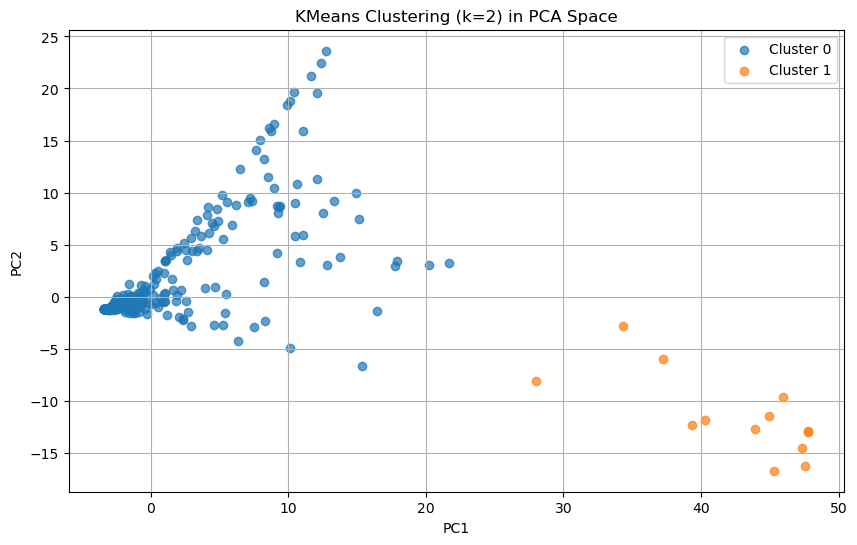

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for cl in sorted(account_df["cluster_2"].unique()):
    subset = account_df[account_df["cluster_2"] == cl]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {cl}", alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clustering (k=2) in PCA Space")
plt.legend()
plt.grid(True)
plt.show()

Based on the silhouette scores, the strongest natural segmentation appears at k=2, with a score of 0.8528.
This suggests that the existing accounts are most cleanly separated into two broad geospatial/network patterns.
We therefore use the 2-cluster solution as the primary segmentation, while also testing k=3 as a secondary, more granular view.

v2 clustering

In [13]:
feature_cols_v2 = [
    "avg_tgt_4mi",
    "avg_tgt_3mi",
    "avg_tgt_2mi",
    "med_tgt_4mi",
    "med_tgt_3mi",
    "med_tgt_2mi",
    "lat_std",
    "lon_std"
]

In [14]:
from sklearn.preprocessing import RobustScaler

X_v2 = account_df[feature_cols_v2].copy()

scaler_v2 = RobustScaler()
X_v2_scaled = scaler_v2.fit_transform(X_v2)

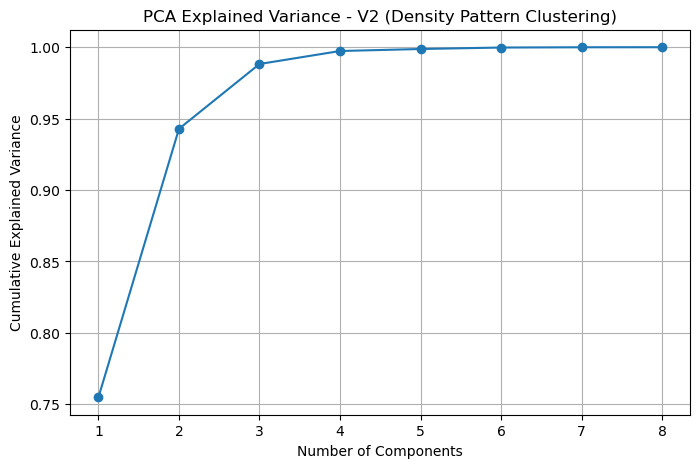

Explained variance ratio: [7.54976809e-01 1.87910635e-01 4.53739030e-02 9.08361703e-03
 1.41073288e-03 1.02527675e-03 1.87176160e-04 3.18495885e-05]
Cumulative explained variance: [0.75497681 0.94288744 0.98826135 0.99734496 0.9987557  0.99978097
 0.99996815 1.        ]


In [15]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca_v2 = PCA()
X_v2_pca_all = pca_v2.fit_transform(X_v2_scaled)

explained_v2 = np.cumsum(pca_v2.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_v2)+1), explained_v2, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance - V2 (Density Pattern Clustering)")
plt.grid(True)
plt.show()

print("Explained variance ratio:", pca_v2.explained_variance_ratio_)
print("Cumulative explained variance:", explained_v2)

In [16]:
from sklearn.decomposition import PCA

pca_v2_final = PCA(n_components=2, random_state=42)
X_v2_pca = pca_v2_final.fit_transform(X_v2_scaled)

print("Original V2 shape:", X_v2_scaled.shape)
print("V2 PCA shape:", X_v2_pca.shape)
print("V2 explained variance ratio:", pca_v2_final.explained_variance_ratio_)
print("V2 cumulative explained variance:", pca_v2_final.explained_variance_ratio_.cumsum())

Original V2 shape: (568, 8)
V2 PCA shape: (568, 2)
V2 explained variance ratio: [0.75497681 0.18791064]
V2 cumulative explained variance: [0.75497681 0.94288744]


In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores_v2 = []

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_v2_pca)
    score = silhouette_score(X_v2_pca, labels)
    scores_v2.append((k, score))

print("Silhouette scores by k for V2:")
for k, score in scores_v2:
    print(f"k={k}: {score:.4f}")

Silhouette scores by k for V2:
k=2: 0.7606
k=3: 0.7297
k=4: 0.7123
k=5: 0.5137
k=6: 0.5382


In [18]:
from sklearn.cluster import KMeans

kmeans_v2 = KMeans(n_clusters=3, random_state=42, n_init=20)
account_df["cluster_v2"] = kmeans_v2.fit_predict(X_v2_pca)

In [19]:
account_df["v2_PC1"] = X_v2_pca[:, 0]
account_df["v2_PC2"] = X_v2_pca[:, 1]

In [20]:
cluster_v2_profile = (
    account_df.groupby("cluster_v2")
    .agg(
        account_count=("account_nbr", "nunique"),

        avg_site_count=("site_count", "mean"),
        med_site_count=("site_count", "median"),
        avg_state_count=("state_count", "mean"),
        med_state_count=("state_count", "median"),

        avg_avg_tgt_4mi=("avg_tgt_4mi", "mean"),
        avg_avg_tgt_3mi=("avg_tgt_3mi", "mean"),
        avg_avg_tgt_2mi=("avg_tgt_2mi", "mean"),

        avg_med_tgt_4mi=("med_tgt_4mi", "mean"),
        avg_med_tgt_3mi=("med_tgt_3mi", "mean"),
        avg_med_tgt_2mi=("med_tgt_2mi", "mean"),

        avg_total_tgt_4mi=("total_tgt_4mi", "mean"),
        avg_total_tgt_3mi=("total_tgt_3mi", "mean"),
        avg_total_tgt_2mi=("total_tgt_2mi", "mean"),

        avg_lat_std=("lat_std", "mean"),
        avg_lon_std=("lon_std", "mean")
    )
    .reset_index()
)

print(cluster_v2_profile)

   cluster_v2  account_count  avg_site_count  med_site_count  avg_state_count  \
0           0            476        9.004202             1.0         1.403361   
1           1             76      384.197368             5.0        11.947368   
2           2             16        1.062500             1.0         1.000000   

   med_state_count  avg_avg_tgt_4mi  avg_avg_tgt_3mi  avg_avg_tgt_2mi  \
0              1.0        10.224249         6.460728         3.497520   
1              4.0        13.620695         8.838929         5.063032   
2              1.0        56.562500        40.531250        25.875000   

   avg_med_tgt_4mi  avg_med_tgt_3mi  avg_med_tgt_2mi  avg_total_tgt_4mi  \
0         9.915966          6.25000         3.335084          85.924370   
1        11.750000          7.50000         4.302632        3839.578947   
2        56.562500         40.53125        25.875000          62.937500   

   avg_total_tgt_3mi  avg_total_tgt_2mi  avg_lat_std  avg_lon_std  
0          56

In [21]:
for cl in sorted(account_df["cluster_v2"].unique()):
    print(f"\n===== V2 Cluster {cl} sample accounts =====")
    cols = [
        "account_nbr", "customer_name", "site_count", "state_count",
        "avg_tgt_4mi", "avg_tgt_3mi", "avg_tgt_2mi",
        "med_tgt_4mi", "med_tgt_3mi", "med_tgt_2mi",
        "lat_std", "lon_std"
    ]
    print(
        account_df[account_df["cluster_v2"] == cl][cols]
        .sort_values(["avg_tgt_4mi", "avg_tgt_3mi"], ascending=False)
        .head(15)
    )


===== V2 Cluster 0 sample accounts =====
    account_nbr   customer_name  site_count  state_count  avg_tgt_4mi  \
330     7431065           Metro           1            1    48.000000   
554     9986089  Ahold Delhaize           1            1    46.000000   
166    40714038  Ahold Delhaize           1            1    38.000000   
311     7427471          Macy's           1            1    37.000000   
285     7392961          Macy's           3            3    35.333333   
550       99578          Macy's           1            1    35.000000   
49       169025          Macy's           1            1    34.000000   
292     7393048           Metro           1            1    34.000000   
114       30113          Macy's           1            1    33.000000   
374     8141025  Ahold Delhaize           1            1    32.000000   
73        27555          Macy's           1            1    32.000000   
91        27939     Dollar Tree           1            1    32.000000   
328     7

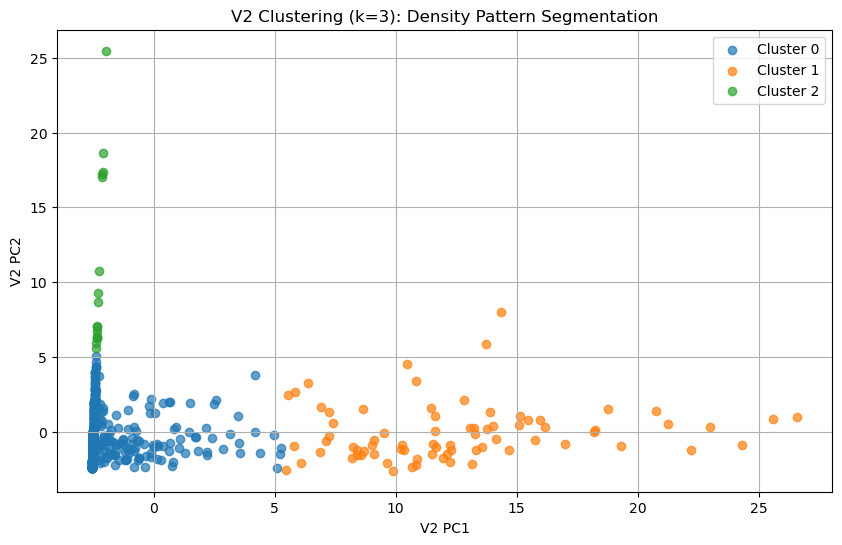

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for cl in sorted(account_df["cluster_v2"].unique()):
    subset = account_df[account_df["cluster_v2"] == cl]
    plt.scatter(subset["v2_PC1"], subset["v2_PC2"], label=f"Cluster {cl}", alpha=0.7)

plt.xlabel("V2 PC1")
plt.ylabel("V2 PC2")
plt.title("V2 Clustering (k=3): Density Pattern Segmentation")
plt.legend()
plt.grid(True)
plt.show()